1. Druk op tools
2. Druk op API Overview
3. Kopieer de Private AI Token en kopieer die hieronder onder "TOKEN"

Totaal m² (AI MASKS ≥ 0.5):  12360.19

 Er is validatie data gevonden:
Ingetekende areas: 114
Totaal m² ingetekend: 10505.31
Gemiddeld per area: 92.15 m²


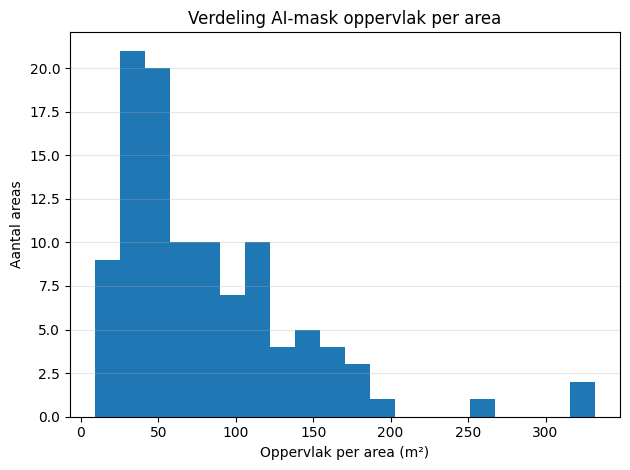

In [ ]:
import requests
import matplotlib.pyplot as plt

# --- Config ---
TOKEN       = "Voeg hier de overlay toe binnen de haakjes"
BASE        = "https://preview.tygron.com/api/session"
MIN_MASK    = "0.5"
MIN_SCORE   = "0.5"
EXPECTED_NN = "inference_2c_25cm_25e_250_maxgt"
TIMEOUT     = 15

params_json = {"crs": "3857", "f": "JSON", "token": TOKEN}

def qtext(q: str) -> str:
    r = requests.post(f"{BASE}/query/", params={"token": TOKEN}, data={"0": q}, timeout=TIMEOUT)
    return (r.text or "").strip()

def qfloat(q: str) -> float:
    t = qtext(q).replace(",", ".")
    try:
        return float(t)
    except Exception:
        return 0.0

overlays = requests.get(f"{BASE}/items/overlays/", params=params_json, timeout=TIMEOUT).json()
score_cnt = sum(o.get("resultType") == "SCORES" for o in overlays)
mask_cnt  = sum(o.get("resultType") == "MASKS"  for o in overlays)
inference = next((o for o in overlays if o.get("type") == "INFERENCE"), None)

assert score_cnt == 1, "Er moet precies 1 SCORES-overlay zijn."
assert mask_cnt  == 1, "Er moet precies 1 MASKS-overlay zijn."
assert inference is not None, "INFERENCE parent overlay ontbreekt."
assert int(inference.get("neuralNetworkID", -1)) >= 0, "Geen neuralNetworkID op INFERENCE overlay."

nn = requests.get(f"{BASE}/items/neuralnetworks/{inference['neuralNetworkID']}",
                  params=params_json, timeout=TIMEOUT).json()
assert nn.get("name") == EXPECTED_NN, f'Update EXPECTED_NN naar "{nn.get("name")}".'

total_mask_m2  = qfloat(f"SELECT_GRIDAREA_WHERE_RESULTTYPE_IS_MASKS_AND_MINGRIDVALUE_IS_{MIN_MASK}")
total_score_m2 = qfloat(f"SELECT_GRIDAREA_WHERE_RESULTTYPE_IS_SCORES_AND_MINGRIDVALUE_IS_{MIN_SCORE}")

print(f"Totaal m² (AI MASKS ≥ {MIN_MASK}):  {total_mask_m2:.2f}")
print(f"Totaal m² (AI SCORES ≥ {MIN_SCORE}): {total_score_m2:.2f}")

Alleen areas laten zien als ze er zijn 
areas = requests.get(f"{BASE}/items/areas/", params=params_json, timeout=TIMEOUT).json()
if areas:  # <-- alleen draaien als er areas zijn
    print("\\n Er is validatie data gevonden:")
    total_drawn_m2 = 0.0
    mask_m2_per_area = []

    for a in areas:
        aid = a["id"]
        # totale m² van het ingetekende area
        total_drawn_m2 += qfloat(f"SELECT_GRIDAREA_WHERE_AREA_IS_{aid}")
        m_mask = qfloat(
            f"SELECT_GRIDAREA_WHERE_RESULTTYPE_IS_MASKS_AND_MINGRIDVALUE_IS_{MIN_MASK}_AND_AREA_IS_{aid}"
        )
        if m_mask > 0:
            mask_m2_per_area.append(m_mask)

    n = len(areas)
    avg = total_drawn_m2 / n if n else 0.0
    print(f"Ingetekende areas: {n}")
    print(f"Totaal m² ingetekend: {total_drawn_m2:.2f}")
    print(f"Gemiddeld per area: {avg:.2f} m²")

    # Plot alleen als we AI-mask m² per area hebben
    if mask_m2_per_area:
        plt.figure()
        plt.hist(mask_m2_per_area, bins=20)
        plt.title("Verdeling ingetekende oppervlak per area")
        plt.xlabel("Oppervlak per area (m²)")
        plt.ylabel("Aantal areas")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()